## Notebook with analysis pertaining to Figure 4 and S4
Also contains code to export data for Supplemental Tables 12,13

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.mode.copy_on_write = True

plt.rcParams['axes.spines.top'] = False # remove top spine
plt.rcParams['axes.spines.right'] = False # remove right spine
plt.rcParams['pdf.fonttype'] = 42 # Set the fonttype to export fonts as font files
plt.rcParams['font.family'] = 'Arial'
sns.set_palette("colorblind")
global_fontsize = 12
global_color = 'tab:grey'

In [ ]:
# From annotations/add_annot_to_clusters.ipynb
pdb_clusters = pd.read_csv("/Volumes/imb-luckgr/projects/interface_clustering/results/cluster_analysis/pdb_clusters_annotated.tsv", sep="\t")
pdb_clusters["chain_id_0"] = pdb_clusters["chain_id_0"].fillna('NA')
pdb_clusters["chain_id_1"] = pdb_clusters["chain_id_1"].fillna('NA')

# From annotations/create_cluster_summary.ipynb
cluster_summary = pd.read_csv("/Volumes/imb-luckgr/projects/interface_clustering/results/cluster_analysis/pdb_cluster_summary.tsv", sep="\t")

# Identify assemblies with only one interface (dimer assemblies)
num_if_per_pdb = pdb_clusters.groupby("pdb_id")["old_complex_id"].size()
single_dimers = list(set(num_if_per_pdb[num_if_per_pdb == 1].index))
print(len(single_dimers))
pdb_clusters.loc[:, "single_dimer"] = 0
pdb_clusters.loc[pdb_clusters["pdb_id"].isin(single_dimers), "single_dimer"] = 1
print(pdb_clusters[pdb_clusters["single_dimer"] == 1].shape[0])

# Dataset generated in af_new_if-types.ipynb
results_df = pd.read_csv("/Volumes/imb-luckgr/projects/interface_clustering/results/afmm_benchmarking.tsv", sep="\t")
print("Number of rows without DockQ value:", results_df[results_df["DockQ"].isna()].shape[0])

results_df["single_dimer"] = results_df["old_complex_id"].map(dict(zip(pdb_clusters.old_complex_id, pdb_clusters.single_dimer)))
results_df["pdb_resolution"] = results_df["old_complex_id"].map(dict(zip(pdb_clusters.old_complex_id, pdb_clusters.pdb_resolution)))
results_df["pdb_expt_method"] = results_df["old_complex_id"].map(dict(zip(pdb_clusters.old_complex_id, pdb_clusters.pdb_expt_method)))

# Dataset generated in humanppi_vs_pdb.ipynb
humanppi_cluster = pd.read_csv("/Volumes/imb-luckgr/projects/interface_clustering/results/bfmdvspdb/humanppi_cluster_plusannot.tsv", sep="\t")

/var/folders/8n/b4ym5rbn48v7d2lxw_5ph7z40000gp/T/ipykernel_21354/3803548349.py:1: DtypeWarning: Columns (32,34) have mixed types. Specify dtype option on import or set low_memory=False.
  pdb_clusters = pd.read_csv("/Volumes/imb-luckgr/projects/interface_clustering/results/cluster_analysis/pdb_clusters_annotated.tsv", sep="\t")


97200
97200
Number of rows without DockQ value: 130


In [5]:
results_df.loc[results_df["DockQ"] >= 0, "DockQabove0.23"] = 0
results_df.loc[results_df["DockQ"] > 0.23, "DockQabove0.23"] = 1
top_rank_only = results_df[results_df["rank"] == 1]
results_df_nonan = results_df.dropna(subset=["DockQ"], axis=0)
top_rank_only_nonan = top_rank_only.dropna(subset=["DockQ"], axis=0)
top_rank_only_singdim = top_rank_only_nonan[top_rank_only_nonan["single_dimer"] == 1]

In [6]:
humanppi_cluster_hits = humanppi_cluster.groupby("cluster_id")[["pdb_singlechain_hit","pdb_doublechain_hit"]].sum()
humanppi_cluster_hits.columns = ["pdb_singlechain_hit","pdb_doublechain_hit"]
humanppi_cluster_hits["cluster_size"] = humanppi_cluster_hits.index.map(dict(zip(humanppi_cluster.cluster_id, humanppi_cluster.cluster_size)))

humanppi_cluster_hits["mean_meaniplddt"] = humanppi_cluster_hits.index.map(dict(zip(humanppi_cluster["cluster_id"], humanppi_cluster.mean_meaniplddt)))
humanppi_cluster_hits["max_meaniplddt"] = humanppi_cluster_hits.index.map(dict(zip(humanppi_cluster["cluster_id"], humanppi_cluster.max_meaniplddt)))

humanppi_cluster_hits.loc[:, "singleton"] = "Singleton"
humanppi_cluster_hits.loc[humanppi_cluster_hits["cluster_size"] > 1, "singleton"] = "Non-singleton"

humanppi_cluster_hits.loc[:, "status"] = ""
humanppi_cluster_hits.loc[humanppi_cluster_hits["pdb_doublechain_hit"] > 0, "status"] = "Full PDB Match"
humanppi_cluster_hits.loc[((humanppi_cluster_hits["pdb_doublechain_hit"] == 0) & (humanppi_cluster_hits["pdb_singlechain_hit"] > 0)), "status"] = "Partial PDB Match"
humanppi_cluster_hits.loc[humanppi_cluster_hits["pdb_singlechain_hit"] == 0, "status"] = "No PDB Match"

## Supplemental Tables 12,13

In [ ]:
# Table S13
no_hit_clusters = list(set(humanppi_cluster_hits[humanppi_cluster_hits["status"] != "Full PDB Match"].index))
print(len(no_hit_clusters))
humanppi_cluster.loc[:, "cluster_rep"] = 0
humanppi_cluster.loc[humanppi_cluster["rep"] == humanppi_cluster["mem"], "cluster_rep"] = 1
humanppi_cluster_tocsv = humanppi_cluster.drop(["rep", "dimer_id", "coil_status", "coil_status_label"], axis=1)
humanppi_cluster_tocsv = humanppi_cluster_tocsv[humanppi_cluster_tocsv["cluster_id"].isin(no_hit_clusters)]
humanppi_cluster_tocsv.to_csv("/Volumes/imb-luckgr/projects/interface_clustering/datasets/supplemental_tables/humanppi_novel_clusters.csv", index=None)

1780


In [ ]:
# Table S12
afmm_tocsv = top_rank_only_nonan.drop(["report_lookup_id"], axis=1)
afmm_tocsv.to_csv("/Volumes/imb-luckgr/projects/interface_clustering/datasets/supplemental_tables/afmm_benchmarking.csv", index=None)

## Fig. 4
## Panel a

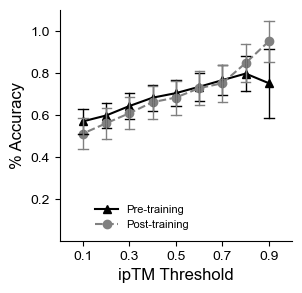

In [ ]:
# Calculate accuracy percentages at increasing ipTM thresholds for pre-training and post-training subsets
iptm_threshs = [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]
pre_training_accs = []
post_training_accs = []
pre_training_errs = []
post_training_errs = []

for x in iptm_threshs:
    pre_training_dockq = top_rank_only_singdim[((top_rank_only_singdim["AFstatus"] == "Pre-training") & (top_rank_only_singdim["iptm"] > x))]["DockQ"]
    post_training_dockq = top_rank_only_singdim[((top_rank_only_singdim["AFstatus"] == "Post-training") & (top_rank_only_singdim["iptm"] > x))]["DockQ"]
    pre_train_sampsize = len(pre_training_dockq)
    post_train_sampsize = len(post_training_dockq)
    pre_training_acc = len(pre_training_dockq[pre_training_dockq > 0.23]) / len(pre_training_dockq)
    post_training_acc = len(post_training_dockq[post_training_dockq > 0.23]) / len(post_training_dockq)
    pre_training_err = 2 * ((pre_training_acc * (1-pre_training_acc) / pre_train_sampsize) ** (1/2))
    post_training_err = 2 * ((post_training_acc * (1-post_training_acc) / post_train_sampsize) ** (1/2))
    pre_training_accs.append(pre_training_acc)
    post_training_accs.append(post_training_acc)
    pre_training_errs.append(pre_training_err)
    post_training_errs.append(post_training_err)

fig, ax = plt.subplots(figsize=(3,3))
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
ax.plot(iptm_threshs, pre_training_accs, marker="^", linestyle="solid", color="black", label="Pre-training")
ax.plot(iptm_threshs, post_training_accs, marker="o", linestyle="dashed", color="gray", label="Post-training")

for i in range(0,len(iptm_threshs)):

    line_err_plus_pre = mpl.lines.Line2D([iptm_threshs[i], iptm_threshs[i]], [pre_training_accs[i], (pre_training_accs[i] + pre_training_errs[i])],
                        lw=1, color='black', axes=ax)
    line_err_minus_pre = mpl.lines.Line2D([iptm_threshs[i], iptm_threshs[i]], [pre_training_accs[i], (pre_training_accs[i] - pre_training_errs[i])],
                        lw=1, color='black', axes=ax)
    line_err_plus_h_pre = mpl.lines.Line2D([(iptm_threshs[i] + 0.02), (iptm_threshs[i] - 0.02)], [(pre_training_accs[i] + pre_training_errs[i]), (pre_training_accs[i] + pre_training_errs[i])],
                        lw=1, color='black', axes=ax)
    line_err_minus_h_pre = mpl.lines.Line2D([(iptm_threshs[i] + 0.02), (iptm_threshs[i] - 0.02)], [(pre_training_accs[i] - pre_training_errs[i]), (pre_training_accs[i] - pre_training_errs[i])],
                        lw=1, color='black', axes=ax)
    ax.add_line(line_err_plus_pre)
    ax.add_line(line_err_minus_pre)
    ax.add_line(line_err_plus_h_pre)
    ax.add_line(line_err_minus_h_pre)
    line_err_plus_post = mpl.lines.Line2D([iptm_threshs[i], iptm_threshs[i]], [post_training_accs[i], (post_training_accs[i] + post_training_errs[i])],
                        lw=1, color='gray', axes=ax)
    line_err_minus_post = mpl.lines.Line2D([iptm_threshs[i], iptm_threshs[i]], [post_training_accs[i], (post_training_accs[i] - post_training_errs[i])],
                        lw=1, color='gray', axes=ax)
    line_err_plus_h_post = mpl.lines.Line2D([(iptm_threshs[i] + 0.02), (iptm_threshs[i] - 0.02)], [(post_training_accs[i] + post_training_errs[i]), (post_training_accs[i] + post_training_errs[i])],
                        lw=1, color='gray', axes=ax)
    line_err_minus_h_post = mpl.lines.Line2D([(iptm_threshs[i] + 0.02), (iptm_threshs[i] - 0.02)], [(post_training_accs[i] - post_training_errs[i]), (post_training_accs[i] - post_training_errs[i])],
                        lw=1, color='gray', axes=ax)
    ax.add_line(line_err_plus_post)
    ax.add_line(line_err_minus_post)
    ax.add_line(line_err_plus_h_post)
    ax.add_line(line_err_minus_h_post)

ax.set_ylim([0,1.1])
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xlim([0,1.0])
ax.set_xticks([0.1, 0.3, 0.5, 0.7, 0.9])
ax.set_xlabel("ipTM Threshold", fontsize=12)
ax.set_ylabel("% Accuracy", fontsize=12)
ax.tick_params(axis="both", labelsize=10)
ax.legend(loc=0, bbox_to_anchor=(0.6, 0.2), frameon=False, title=None, fontsize=8)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/afmm_benchmarking_iptmthreshs.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/afmm_benchmarking_iptmthreshs.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

## Panel c

In [15]:
humanppi_cluster_hits.groupby("status")["singleton"].value_counts()

status             singleton    
Full PDB Match     Singleton        6660
                   Non-singleton    1600
No PDB Match       Singleton         112
                   Non-singleton       1
Partial PDB Match  Singleton        1611
                   Non-singleton      56
Name: count, dtype: int64

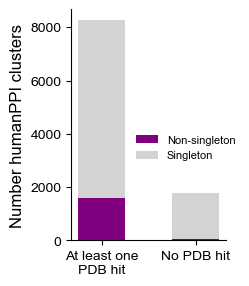

In [16]:
fig, ax = plt.subplots(figsize=(2,3))
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)

ax.bar(x="At least one\nPDB hit", height=1600, width=0.5, bottom=0, color="purple", label="Non-singleton")
ax.bar(x="At least one\nPDB hit", height=6660, width=0.5, bottom=1600, color="lightgray", label="Singleton")
ax.bar(x="No PDB hit", height=57, width=0.5, bottom=0, color="purple")
ax.bar(x="No PDB hit", height=1723, width=0.5, bottom=57, color="lightgray")

ax.tick_params(axis='both', labelsize=10)
ax.set_ylabel("Number humanPPI clusters", fontsize=12)

ax.legend(loc=0, bbox_to_anchor=(0.35,0.5), frameon=False, fontsize=8, title=None)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/humanppi_numclust_barplot.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/humanppi_numclust_barplot.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

## Panel d
See enrichGO_humanppi_nohit.R

## Fig. S4
## Panel a

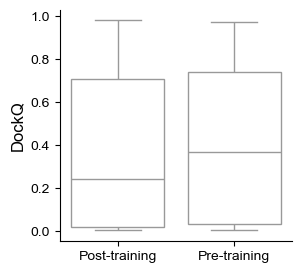

In [7]:
fig, ax = plt.subplots(figsize=(3,3))
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
sns.boxplot(data=top_rank_only_singdim, y="DockQ", x="AFstatus", color="white", ax=ax)
ax.set_xlabel(None)
ax.set_ylabel("DockQ", fontsize=12)
ax.tick_params(axis='both', labelsize=10)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/afmm_benchmarking_dockqbox.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/afmm_benchmarking_dockqbox.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

## Panel b

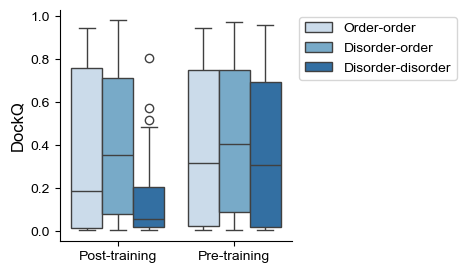

In [8]:
fig, ax = plt.subplots(figsize=(3,3))
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
sns.boxplot(data=top_rank_only_singdim, y="DockQ", x="AFstatus", hue="if_type", palette="Blues", ax=ax)
ax.set_xlabel(None)
ax.set_ylabel("DockQ", fontsize=12)
ax.tick_params(axis='both', labelsize=10)
ax.legend(loc=0, bbox_to_anchor=(1.0,1.0), frameon=True, title=None)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/afmm_benchmarking_bydisorder.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/afmm_benchmarking_bydisorder.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

## Panel c

/var/folders/8n/b4ym5rbn48v7d2lxw_5ph7z40000gp/T/ipykernel_75894/974722053.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Larger complex' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  top_rank_only.loc[top_rank_only["single_dimer"] == 0, "single_dimer"] = "Larger complex"


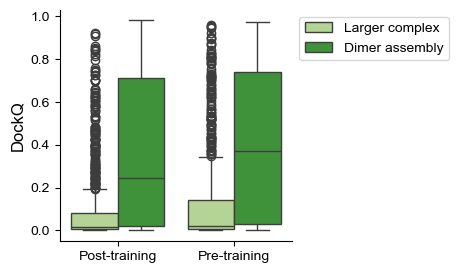

In [9]:
palette = sns.color_palette("Paired")[2:4]
top_rank_only.loc[top_rank_only["single_dimer"] == 0, "single_dimer"] = "Larger complex"
top_rank_only.loc[top_rank_only["single_dimer"] == 1, "single_dimer"] = "Dimer assembly"
fig, ax = plt.subplots(figsize=(3,3))
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
sns.boxplot(data=top_rank_only, x="AFstatus", y="DockQ", hue="single_dimer", palette=palette, ax=ax)
ax.set_xlabel(None)
ax.set_ylabel("DockQ", fontsize=12)
ax.tick_params(axis='both', labelsize=10)
ax.legend(loc=0, bbox_to_anchor=(1.0,1.0), frameon=True, title=None)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/afmm_benchmarking_bydimer.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/afmm_benchmarking_bydimer.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

## Panel d

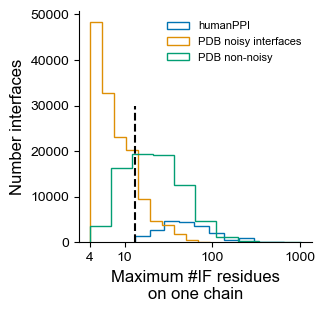

In [21]:
noisy_cluster_ids = list(set(cluster_summary[cluster_summary["cluster_qtm"] < 0.5]["intcluster"]))
fig, ax = plt.subplots(figsize=(3,3))
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
ax.hist([np.log10(x) for x in humanppi_cluster["max_if_len"]], histtype='step', label="humanPPI")
ax.hist([np.log10(x) for x in pdb_clusters[pdb_clusters["intcluster"].isin(noisy_cluster_ids)]["maxiflen"]], histtype='step', label="PDB noisy interfaces")
ax.hist([np.log10(x) for x in pdb_clusters[((~pdb_clusters["intcluster"].isin(noisy_cluster_ids)) & (pdb_clusters["intrep"] == 1))]["maxiflen"]], histtype='step', label="PDB non-noisy")
ax.vlines(x=np.log10(13), ymin=0, ymax=30000, linestyle="dashed", color="black")
ax.set_xticks([np.log10(4), np.log10(10), np.log10(100), np.log10(1000)])
ax.set_xticklabels(["4","10","100","1000"])
ax.tick_params(axis='both', labelsize=10)
ax.set_xlabel("Maximum #IF residues\non one chain", fontsize=12)
ax.set_ylabel("Number interfaces", fontsize=12)
ax.legend(loc=0, bbox_to_anchor=(1.0,1.0), frameon=False, title=None, fontsize=8)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/humanppi_iflen_histplot.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/humanppi_iflen_histplot.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

## Panel e

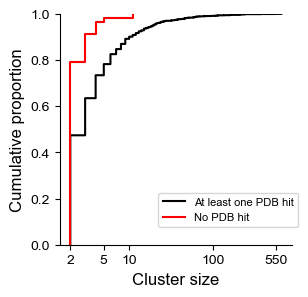

In [22]:
logs1 = [np.log10(x) for x in humanppi_cluster_hits[humanppi_cluster_hits["pdb_doublechain_hit"] > 0]["cluster_size"]]
logs2 = [np.log10(x) for x in humanppi_cluster_hits[humanppi_cluster_hits["pdb_doublechain_hit"] == 0]["cluster_size"]]
logs1 = [x for x in logs1 if x > 0]
logs2 = [x for x in logs2 if x > 0]

fig, ax = plt.subplots(figsize=(3,3))
ax.ecdf(logs1, label='At least one PDB hit', color='black')
ax.ecdf(logs2, label='No PDB hit', color='red')
ax.set_xlabel('Cluster size', fontsize=global_fontsize, color='black')
ax.set_ylabel('Cumulative proportion', fontsize=global_fontsize, color='black')
ax.set_xticks([np.log10(2),np.log10(5),np.log10(10),np.log10(100),np.log10(550)])
ax.set_xticklabels(['2','5','10','100','550'], fontsize=10)
ax.tick_params(axis='both', labelsize=10, labelcolor='black', color='black')
ax.legend(loc=0, bbox_to_anchor=(1.05,0.25), frameon=True, fontsize=8, title=None)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/humanppi_clustersize_cdf.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/humanppi_clustersize_cdf.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

## Panel f

In [24]:
full_matches = list(set(humanppi_cluster_hits[humanppi_cluster_hits["pdb_doublechain_hit"] > 0].index))
non_matches = list(set(humanppi_cluster_hits[humanppi_cluster_hits["pdb_doublechain_hit"] == 0].index))
print(humanppi_cluster[humanppi_cluster["cluster_id"].isin(full_matches)].groupby("cluster_id")["if_type"].apply(lambda x: x.value_counts().idxmax()).value_counts())
print(humanppi_cluster[humanppi_cluster["cluster_id"].isin(non_matches)].groupby("cluster_id")["if_type"].apply(lambda x: x.value_counts().idxmax()).value_counts())

if_type
Order-order          6326
Disorder-order       1733
Disorder-disorder     156
Unannotated            45
Name: count, dtype: int64
if_type
Order-order          1337
Disorder-order        402
Disorder-disorder      33
Unannotated             8
Name: count, dtype: int64


In [25]:
cluster_summary["top_discat"].value_counts()

top_discat
Order-order          51364
Unannotated          13590
Disorder-order       10029
Disorder-disorder     2184
Name: count, dtype: int64

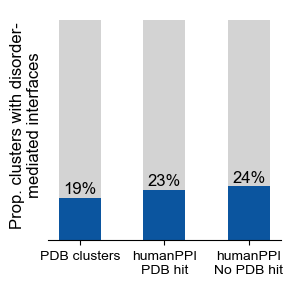

In [26]:
pdb_dispct = (10029 + 2183) / (10029 + 2183 + 51364)

hit_dispct = (1733 + 156) / (1733 + 156 + 6326)

nohit_dispct = (402 + 33) / (402 + 33 + 1337)

fig, ax = plt.subplots(figsize=(3,3))
ax.spines.left.set_visible(False)
ax.bar([0,1,2], [pdb_dispct, hit_dispct, nohit_dispct], 0.5, bottom=[0, 0, 0], color="#0b559f")
ax.bar([0,1,2], [1-pdb_dispct, 1-hit_dispct, 1-nohit_dispct], 0.5, bottom=[pdb_dispct, hit_dispct, nohit_dispct], color="lightgray")
ax.tick_params(axis="both", labelsize=10)
ax.text(0, pdb_dispct+0.02, "19%", fontsize=12, horizontalalignment='center')
ax.text(1, hit_dispct+0.02, "23%", fontsize=12, horizontalalignment='center')
ax.text(2, nohit_dispct+0.02, "24%", fontsize=12, horizontalalignment='center')
ax.set_yticks([])
ax.set_xticks([0,1,2])
ax.set_xticklabels(["PDB clusters","humanPPI\nPDB hit","humanPPI\nNo PDB hit"])
ax.set_ylabel("Prop. clusters with disorder-\nmediated interfaces", fontsize=12)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/humanppi_disorder_barplot.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/humanppi_disorder_barplot.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')